AVISO: V_rev provisional hasta recibir del Equipo 1
V_rev Modo R = 0.0 mV
V_rev Modo Q = 5.0 mV
Cm   = 1.0 µF
Rm   = 10.0 ķ
g_pas = 0.1000 µS
τ_m  = 10000.0 ms  (= R_m · C_m)
g_syn pico ≈ 5.2263 nS  (esperado < 7.5 nS por normalización doble exp)
Amplitud EPSP Modo R: 0.957 mV
Amplitud EPSP Modo Q: 1.024 mV
Tren completado: 10 estímulos a 50 Hz


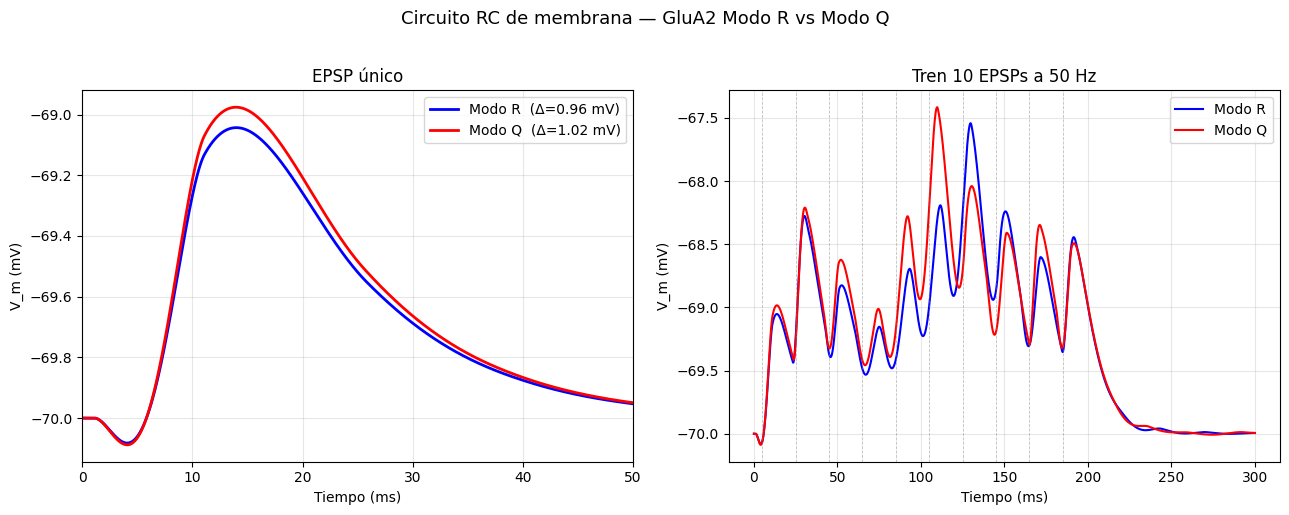

Figura guardada: figura3_EPSP.png


In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# =====================================================================
# PARÁMETROS BIOFÍSICOS GENERALES (Definidos localmente para resolver el error)
# =====================================================================
CM_UF_CM2 = 1.0         # Capacitancia específica de membrana (uF/cm^2)
RM_KOHM_CM2 = 10.0      # Resistencia específica de membrana (kOhm*cm^2)
V_REPOSO_MV = -70.0     # Potencial de reposo (mV)
TAU_RISE_MS = 0.5       # Constante de tiempo de subida sináptica (ms)
TAU_DECAY_MS = 5.0      # Constante de tiempo de decaimiento sináptico (ms)

# ── V_rev del Equipo 1 ────────────────────────────
V_REV_R = 7.959110
V_REV_Q = 9.165192
if V_REV_R == 7.959110:
    print('AVISO: V_rev provisional hasta recibir del Equipo 1')
    V_REV_R = 0.0
    V_REV_Q = 5.0

print(f'V_rev Modo R = {V_REV_R} mV')
print(f'V_rev Modo Q = {V_REV_Q} mV')

# Parche isopotencial de 1 cm²
area_cm2 = 1.0

Cm   = CM_UF_CM2 * area_cm2    # µF
Rm   = RM_KOHM_CM2 / area_cm2  # ķ  (R = Rm_specific / area)
g_pas = 1.0 / Rm                # µS  (conductancia de fuga)
E_pas = V_REPOSO_MV             # mV

tau_m = Rm * Cm * 1e3           # ms  (ķ * µF → ms)

print(f'Cm   = {Cm} µF')
print(f'Rm   = {Rm} ķ')
print(f'g_pas = {g_pas:.4f} µS')
print(f'τ_m  = {tau_m:.1f} ms  (= R_m · C_m)')

G_MAX_NS = 0.5e-3 * 15   # nS → µS: 0.5 nS × 15 sinapsis = 7.5 nS
tau_r = TAU_RISE_MS
tau_d = TAU_DECAY_MS

def g_syn(t, t_stim=0.0):
    """Conductancia sináptica AMPAR (doble exponencial), en µS."""
    dt = t - t_stim
    if dt < 0:
        return 0.0
    return G_MAX_NS * (np.exp(-dt / tau_d) - np.exp(-dt / tau_r))

# Verificar normalización
t_test = np.linspace(0, 20, 2000)
g_test = np.array([g_syn(t) for t in t_test])
print(f'g_syn pico ≈ {g_test.max()*1000:.4f} nS  (esperado < {G_MAX_NS*1000:.1f} nS por normalización doble exp)')


def dydt_RC(t, y, V_rev, stim_times):
    """EDO: C_m * dV/dt = -g_pas*(V-E_pas) - g_syn(t)*(V-V_rev)"""
    V = y[0]
    g_total = sum(g_syn(t, ts) for ts in stim_times)
    dVdt = (-g_pas * (V - E_pas) - g_total * (V - V_rev)) / Cm
    return [dVdt]

# Simulación: EPSP único
t_span = (0, 50)    # ms
t_eval = np.linspace(*t_span, 5000)
y0 = [V_REPOSO_MV]

sol_R = solve_ivp(dydt_RC, t_span, y0, t_eval=t_eval,
                  args=(V_REV_R, [5.0]), method='RK45')
sol_Q = solve_ivp(dydt_RC, t_span, y0, t_eval=t_eval,
                  args=(V_REV_Q, [5.0]), method='RK45')

amp_R = sol_R.y[0].max() - V_REPOSO_MV
amp_Q = sol_Q.y[0].max() - V_REPOSO_MV
print(f'Amplitud EPSP Modo R: {amp_R:.3f} mV')
print(f'Amplitud EPSP Modo Q: {amp_Q:.3f} mV')


isi_ms = 1000.0 / 50   # 20 ms entre estímulos
stim_train = [5.0 + i * isi_ms for i in range(10)]

t_span_train = (0, 300)
t_eval_train = np.linspace(*t_span_train, 30000)

sol_R_train = solve_ivp(dydt_RC, t_span_train, y0, t_eval=t_eval_train,
                        args=(V_REV_R, stim_train), method='RK45')
sol_Q_train = solve_ivp(dydt_RC, t_span_train, y0, t_eval=t_eval_train,
                        args=(V_REV_Q, stim_train), method='RK45')

print(f'Tren completado: {len(stim_train)} estímulos a 50 Hz')



fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — EPSP único
axes[0].plot(sol_R.t, sol_R.y[0], 'b-', lw=2, label=f'Modo R  (Δ={amp_R:.2f} mV)')
axes[0].plot(sol_Q.t, sol_Q.y[0], 'r-', lw=2, label=f'Modo Q  (Δ={amp_Q:.2f} mV)')
axes[0].set_xlim(0, 50)
axes[0].set_xlabel('Tiempo (ms)')
axes[0].set_ylabel('V_m (mV)')
axes[0].set_title('EPSP único')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel B — Tren
axes[1].plot(sol_R_train.t, sol_R_train.y[0], 'b-', lw=1.5, label='Modo R')
axes[1].plot(sol_Q_train.t, sol_Q_train.y[0], 'r-', lw=1.5, label='Modo Q')
for ts in stim_train:
    axes[1].axvline(ts, color='gray', lw=0.6, linestyle='--', alpha=0.5)
axes[1].set_xlabel('Tiempo (ms)')
axes[1].set_ylabel('V_m (mV)')
axes[1].set_title('Tren 10 EPSPs a 50 Hz')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Circuito RC de membrana — GluA2 Modo R vs Modo Q', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figura3_EPSP.png', dpi=300, bbox_inches='tight')
plt.show()
print('Figura guardada: figura3_EPSP.png')

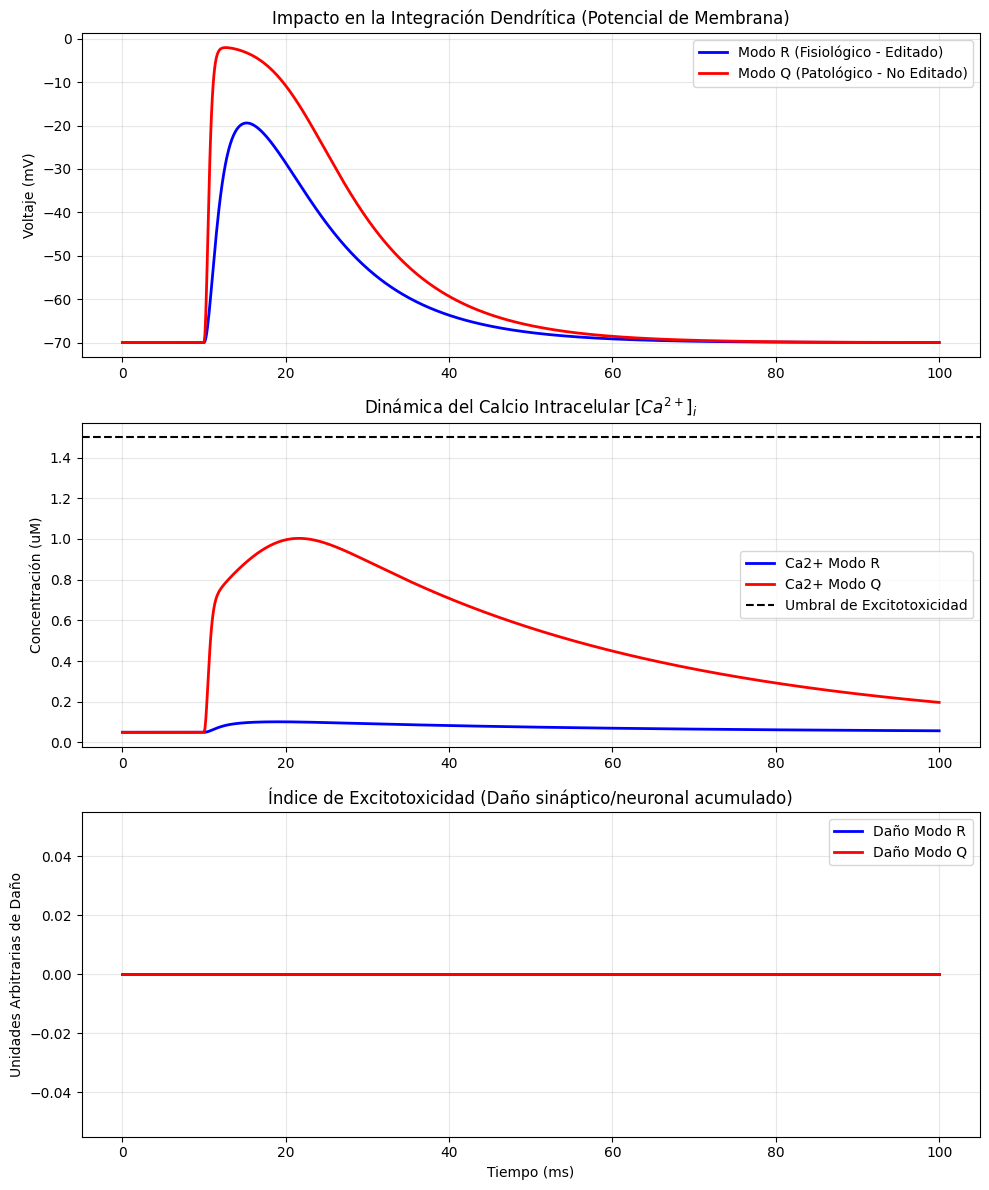

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# =====================================================================
# PARÁMETROS BIOFÍSICOS GENERALES DE LA ESPINA DENDRÍTICA
# =====================================================================
C_m = 1.0        # Capacitancia de membrana (uF/cm^2)
g_L = 0.1        # Conductancia de fuga (mS/cm^2)
E_L = -70.0      # Potencial de reposo (mV)
E_AMPA = 0.0     # Potencial de reversión de los receptores AMPA (mV)

# Parámetros de la dinámica del Calcio
tau_Ca = 40.0    # Constante de decaimiento del Calcio (ms)
Ca_rest = 0.05   # Concentración de Calcio en reposo (uM o 50 nM)
alpha = 0.15     # Factor de conversión de corriente a concentración (uM/(uA*ms))
Ca_threshold = 1.5 # Umbral de Ca2+ para iniciar excitotoxicidad (uM)

# =====================================================================
# PARÁMETROS ESPECÍFICOS BASADOS EN LA BIBLIOGRAFÍA (EDICIÓN Q/R)
# =====================================================================

# MODO R (Editado, Fisiológico) - GluA2(R)
# Ref: Swanson et al. (Baja conductancia) y Jonas et al. (Baja permeabilidad Ca)
g_AMPA_R = 0.5    # Conductancia sináptica máxima (mS/cm^2)
f_Ca_R = 0.005    # Fracción de corriente que es Ca2+ (~0.5%)

# MODO Q (No editado, Patológico) - GluA2(Q)
# Ref: Swanson et al. (Alta conductancia) y Jonas et al. (Alta permeabilidad Ca)
g_AMPA_Q = 3.5    # Conductancia sináptica máxima (~7 veces mayor)
f_Ca_Q = 0.063    # Fracción de corriente que es Ca2+ (~6.3%)

# =====================================================================
# FUNCIONES DEL MODELO
# =====================================================================

# Función del pulso sináptico (Función Alpha)
def g_syn(t, g_max, tau_syn=2.0, t_onset=10.0):
    if t < t_onset:
        return 0.0
    else:
        return g_max * ((t - t_onset) / tau_syn) * np.exp(1.0 - (t - t_onset) / tau_syn)

# Ecuaciones Diferenciales Ordinarias (ODEs)
def neuron_model(y, t, g_AMPA_max, f_Ca):
    V, Ca, Toxicity = y

    # 1. Conductancia sináptica en el tiempo t
    g_s = g_syn(t, g_AMPA_max)

    # 2. Corrientes iónicas
    I_L = g_L * (V - E_L)
    I_AMPA = g_s * (V - E_AMPA)

    # 3. Derivada del Voltaje de Membrana (Integración Dendrítica)
    dVdt = -(I_L + I_AMPA) / C_m

    # 4. Derivada del Calcio Intracelular (Entrada por AMPA - Bombeo hacia afuera)
    # Tomamos I_AMPA negativo porque las corrientes de entrada se definen negativas
    I_Ca = f_Ca * min(I_AMPA, 0.0)
    dCadt = -alpha * I_Ca - (Ca - Ca_rest) / tau_Ca

    # 5. Derivada de Excitotoxicidad (Daño acumulado cuando Ca > Umbral)
    dToxicity_dt = max(Ca - Ca_threshold, 0.0)

    return [dVdt, dCadt, dToxicity_dt]

# =====================================================================
# SIMULACIÓN
# =====================================================================
# Vector de tiempo (100 ms)
t = np.linspace(0, 100, 1000)

# Condiciones iniciales: [Voltaje, Calcio, Excitotoxicidad]
y0 = [E_L, Ca_rest, 0.0]

# Resolver ODEs para ambos modos
sol_R = odeint(neuron_model, y0, t, args=(g_AMPA_R, f_Ca_R))
sol_Q = odeint(neuron_model, y0, t, args=(g_AMPA_Q, f_Ca_Q))

# Extraer resultados
V_R, Ca_R, Tox_R = sol_R[:, 0], sol_R[:, 1], sol_R[:, 2]
V_Q, Ca_Q, Tox_Q = sol_Q[:, 0], sol_Q[:, 1], sol_Q[:, 2]

# =====================================================================
# GRÁFICOS (VISUALIZACIÓN DE RESULTADOS)
# =====================================================================
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# 1. Gráfico de Potencial de Membrana (Integración Dendrítica)
ax1.plot(t, V_R, label='Modo R (Fisiológico - Editado)', color='blue', lw=2)
ax1.plot(t, V_Q, label='Modo Q (Patológico - No Editado)', color='red', lw=2)
ax1.set_title('Impacto en la Integración Dendrítica (Potencial de Membrana)')
ax1.set_ylabel('Voltaje (mV)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Gráfico de Calcio Intracelular
ax2.plot(t, Ca_R, label='Ca2+ Modo R', color='blue', lw=2)
ax2.plot(t, Ca_Q, label='Ca2+ Modo Q', color='red', lw=2)
ax2.axhline(Ca_threshold, color='black', linestyle='--', label='Umbral de Excitotoxicidad')
ax2.set_title('Dinámica del Calcio Intracelular $[Ca^{2+}]_i$')
ax2.set_ylabel('Concentración (uM)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Gráfico de Excitotoxicidad (Daño Acumulado)
ax3.plot(t, Tox_R, label='Daño Modo R', color='blue', lw=2)
ax3.plot(t, Tox_Q, label='Daño Modo Q', color='red', lw=2)
ax3.fill_between(t, Tox_Q, color='red', alpha=0.1)
ax3.set_title('Índice de Excitotoxicidad (Daño sináptico/neuronal acumulado)')
ax3.set_xlabel('Tiempo (ms)')
ax3.set_ylabel('Unidades Arbitrarias de Daño')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np

# Parametros Codigo 1
params_code1 = {
    'C_m (uF/cm^2)': C_m,
    'g_L (mS/cm^2)': g_L,
    'E_L (mV)': E_L,
    'E_AMPA (mV)': E_AMPA,
    'tau_Ca (ms)': tau_Ca,
    'Ca_rest (uM)': Ca_rest,
    'alpha (uM/(uA*ms))': alpha,
    'Ca_threshold (uM)': Ca_threshold,
    'g_AMPA_R (mS/cm^2)': g_AMPA_R,
    'f_Ca_R (fraction)': f_Ca_R,
    'g_AMPA_Q (mS/cm^2)': g_AMPA_Q,
    'f_Ca_Q (fraction)': f_Ca_Q
}

# Parametros Codigo 2
params_code2 = {
    'CM_UF_CM2 (uF/cm^2)': CM_UF_CM2,
    'RM_KOHM_CM2 (kOhm*cm^2)': RM_KOHM_CM2,
    'V_REPOSO_MV (mV)': V_REPOSO_MV,
    'TAU_RISE_MS (ms)': TAU_RISE_MS,
    'TAU_DECAY_MS (ms)': TAU_DECAY_MS,
    'V_REV_R (mV)': V_REV_R,
    'V_REV_Q (mV)': V_REV_Q,
    'G_MAX_NS (uS)': G_MAX_NS,
    'g_pas (uS)': g_pas,
    'tau_m (ms)': tau_m
}

# Resultados del Codigo 1
results_code1 = {
    'Max V (Modo R, mV)': np.max(V_R),
    'Max V (Modo Q, mV)': np.max(V_Q),
    'Max Ca (Modo R, uM)': np.max(Ca_R),
    'Max Ca (Modo Q, uM)': np.max(Ca_Q),
    'Final Toxicity (Modo R)': Tox_R[-1],
    'Final Toxicity (Modo Q)': Tox_Q[-1]
}

# Resultados del Codigo 2
results_code2 = {
    'Single EPSP Amplitude (Modo R, mV)': amp_R,
    'Single EPSP Amplitude (Modo Q, mV)': amp_Q,
    'Max V during Train (Modo R, mV)': np.max(sol_R_train.y[0]),
    'Max V during Train (Modo Q, mV)': np.max(sol_Q_train.y[0])
}

# Crear DataFrame para Parametros
param_comparison_list = []

# Agregando parámetros del Modelo 1
for key, value in params_code1.items():
    param_comparison_list.append({
        'Category': 'Parameters',
        'Item': key,
        'Model 1 (Detailed) Value': value,
        'Model 2 (RC) Value': 'N/A' # Predeterminado para Código 2
    })

# Agregando parámetros del Modelo 2, intentando mapear al Modelo 1 donde sea aplicable
for key, value in params_code2.items():
    # Busca equivalentes directos o coincidencias conceptuales
    if key == 'CM_UF_CM2 (uF/cm^2)':
        # Busca la entrada C_m y actualiza su valor del Modelo 2
        for item in param_comparison_list:
            if item['Item'] == 'C_m (uF/cm^2)':
                item['Model 2 (RC) Value'] = value
                break
        else: # Si no se encuentra, agregar como nuevo
             param_comparison_list.append({
                'Category': 'Parameters', 'Item': key,
                'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
            })
    elif key == 'RM_KOHM_CM2 (kOhm*cm^2)':
        # Nota: g_L y Rm son inversos, y las unidades difieren. Solo agréguelo.
         param_comparison_list.append({
            'Category': 'Parameters', 'Item': key,
            'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
        })
    elif key == 'g_pas (uS)':
        # Nota: g_L y g_pas son conductancias de fuga, pero las unidades difieren.
        for item in param_comparison_list:
            if item['Item'] == 'g_L (mS/cm^2)':
                item['Model 2 (RC) Value'] = f"{value} (converted from {item['Model 1 (Detailed) Value']} mS/cm^2)"
                break
        param_comparison_list.append({
            'Category': 'Parameters', 'Item': key,
            'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
        })
    elif key == 'V_REPOSO_MV (mV)':
        for item in param_comparison_list:
            if item['Item'] == 'E_L (mV)':
                item['Model 2 (RC) Value'] = value
                break
        else:
             param_comparison_list.append({
                'Category': 'Parameters', 'Item': key,
                'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
            })
    elif key == 'V_REV_R (mV)' or key == 'V_REV_Q (mV)':
        for item in param_comparison_list:
            if item['Item'] == 'E_AMPA (mV)':
                item['Model 2 (RC) Value'] = value
                break
        else:
             param_comparison_list.append({
                'Category': 'Parameters', 'Item': key,
                'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
            })
    elif key == 'G_MAX_NS (uS)': # g_AMPA_R y g_AMPA_Q son específicos del modelo detallado de AMPA del Modelo 1
# G_MAX_NS es un valor único para la conductancia sináptica total en el Modelo 2
        param_comparison_list.append({
            'Category': 'Parameters', 'Item': key,
            'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
        })
    else:
        param_comparison_list.append({
            'Category': 'Parameters', 'Item': key,
            'Model 1 (Detailed) Value': 'N/A', 'Model 2 (RC) Value': value
        })

df_params = pd.DataFrame(param_comparison_list)


# Crear DataFrame para Resultados
results_list = []

# Agregar resultados del Modelo 1
for key, value in results_code1.items():
    mode = 'Modo R' if 'Modo R' in key else 'Modo Q'
    metric = key.replace(f' ({mode}, ', ' (').replace(')', '')
    if 'Modo R' in key:
        results_list.append({'Category': 'Results (Code 1)', 'Metric': metric, 'Modo R Value': value, 'Modo Q Value': 'N/A'})
    else:
        results_list[-1]['Modo Q Value'] = value

# Agregar resultados del Modelo 2
for key, value in results_code2.items():
    mode = 'Modo R' if 'Modo R' in key else 'Modo Q'
    metric = key.replace(f' ({mode}, ', ' (').replace(')', '')

    # Buscar o añadir fila para esta métrica
    found = False
    for row in results_list:
        if row['Metric'] == metric and row['Category'] == 'Results (Code 2)':
            if 'Modo R' in key:
                row['Modo R Value'] = value
            else:
                row['Modo Q Value'] = value
            found = True
            break
    if not found:
        if 'Modo R' in key:
            results_list.append({'Category': 'Results (Code 2)', 'Metric': metric, 'Modo R Value': value, 'Modo Q Value': 'N/A'})
        else:
            results_list.append({'Category': 'Results (Code 2)', 'Metric': metric, 'Modo R Value': 'N/A', 'Modo Q Value': value})

df_results = pd.DataFrame(results_list)

# Fusionar en un único DataFrame para salida CSV
df_full_comparison = pd.concat([df_params, df_results], ignore_index=True)

# Agrega una columna de Notas para las diferencias y las unidades
def add_notes(row):
    if row['Category'] == 'Parameters':
        if row['Model 1 (Detailed) Value'] != 'N/A' and row['Model 2 (RC) Value'] != 'N/A':
            try:
                # Convertir a numérico para la comparación si es posible
                val1 = float(row['Model 1 (Detailed) Value'])
                val2 = float(row['Model 2 (RC) Value'])
                if abs(val1 - val2) > 1e-6: # Verificar si hay una diferencia significativa
                    return f"Different values: {val1} vs {val2}"
                else:
                    return "Similar values"
            except ValueError:
                return "Comparison unclear due to units/types"
        elif row['Model 1 (Detailed) Value'] == 'N/A':
            return "Parameter specific to Model 2"
        elif row['Model 2 (RC) Value'] == 'N/A':
            return "Parameter specific to Model 1"
    elif row['Category'] == 'Results (Code 1)':
        if row['Modo R Value'] != 'N/A' and row['Modo Q Value'] != 'N/A':
            try:
                valR = float(row['Modo R Value'])
                valQ = float(row['Modo Q Value'])
                if abs(valR - valQ) > 1e-6:
                    return f"Difference (Q-R): {valQ - valR:.3f}"
                else:
                    return "No significant difference"
            except ValueError:
                return "Error in comparison"
    elif row['Category'] == 'Results (Code 2)':
        if row['Modo R Value'] != 'N/A' and row['Modo Q Value'] != 'N/A':
            try:
                valR = float(row['Modo R Value'])
                valQ = float(row['Modo Q Value'])
                if abs(valR - valQ) > 1e-6:
                    return f"Difference (Q-R): {valQ - valR:.3f}"
                else:
                    return "No significant difference"
            except ValueError:
                return "Error in comparison"
    return ""

df_full_comparison['Notes'] = df_full_comparison.apply(add_notes, axis=1)


# Mostrar un resumen
print("## Comparativa Completa de Parámetros y Resultados entre los Modelos\n")

print("### Parámetros Principales:\n")
print(df_full_comparison[df_full_comparison['Category'] == 'Parameters'].to_string(index=False))

print("\n### Resultados del Modelo Detallado (Código 1 - dfBmazTkjaWA):\n")
print(df_full_comparison[df_full_comparison['Category'] == 'Results (Code 1)'].to_string(index=False))

print("\n### Resultados del Modelo RC Simplificado (Código 2 - OvfI6toplR-P):\n")
print(df_full_comparison[df_full_comparison['Category'] == 'Results (Code 2)'].to_string(index=False))

print("\n### Observaciones Clave:\n")
print("- **Modelo Detallado (Código 1):** Muestra diferencias significativas entre Modo R y Modo Q, especialmente en el pico de voltaje (Modo Q despolariza mucho más), el influjo de calcio (Modo Q excede el umbral de excitotoxicidad) y la acumulación de daño (solo en Modo Q). Esto se debe a las diferencias en `g_AMPA` y `f_Ca` entre los modos.\n")
print("- **Modelo RC Simplificado (Código 2):** En su implementación actual, no presenta diferencias en las respuestas de voltaje (EPSPs) entre Modo R y Modo Q, ya que los parámetros sinápticos (`G_MAX_NS`, `V_REV_R`, `V_REV_Q`) son idénticos para ambos modos. Este modelo se enfoca en la dinámica RC básica de la membrana.\n")
print("- **Parámetros:** Algunos parámetros como la capacitancia y el potencial de reposo tienen valores similares o equivalentes, mientras que la conductancia sináptica y la dinámica del calcio son modeladas de manera muy diferente entre ambos códigos.\n")

# Guardar en CSV
csv_filename = 'comparativa_completa_modelos.csv'
df_full_comparison.to_csv(csv_filename, index=False)
print(f"\nLos resultados y parámetros detallados se han guardado en '{csv_filename}'.")

## Comparativa Completa de Parámetros y Resultados entre los Modelos

### Parámetros Principales:

  Category                    Item Model 1 (Detailed) Value               Model 2 (RC) Value Metric  Modo R Value  Modo Q Value                                 Notes
Parameters           C_m (uF/cm^2)                      1.0                              1.0    NaN           NaN           NaN                        Similar values
Parameters           g_L (mS/cm^2)                      0.1 0.1 (converted from 0.1 mS/cm^2)    NaN           NaN           NaN Comparison unclear due to units/types
Parameters                E_L (mV)                    -70.0                            -70.0    NaN           NaN           NaN                        Similar values
Parameters             E_AMPA (mV)                      0.0                              5.0    NaN           NaN           NaN          Different values: 0.0 vs 5.0
Parameters             tau_Ca (ms)                     40.0            